# 월드컵 2026 Poisson 모델 — 체코(및 누락 FIFA 팀) 복구판

`final_elo2_2026.csv` 는 **이름 불일치로 누락된 실제 FIFA 팀 ~20개**(체코·터키·코트디부아르·카보베르데·북한·홍콩 등)가 빠져 있었다.
대부분 `results_name` ≠ `ranking_name` (예: Ivory Coast ↔ Côte d'Ivoire) 이라 원본 병합 때 떨어진 것이고,
이는 **`all_matched_country_v2.csv` 매핑표가 고치려던 바로 그 문제**다.

**수정 방법**: 원천 `results.csv`(martj42, 체코='Czech Republic' 95경기)에서 누락 팀의 경기를 가져오고,
매핑표로 이름을 CSV 기준에 정규화한 뒤, 누락 팀의 Elo를 **CSV의 `rating` 스케일에 선형 보정**해서 합본한다.
모델은 STRICT 버전(원본 노트북과 동일: `(rating_diff/100, is_home)` → Poisson → Dixon-Coles → 승무패).

마지막에 **MSE·R²(득점 회귀)** 와 **Accuracy·log-loss(승무패 분류)** 를 test dataset에서 보고한다.

In [1]:
# ===== 0. 준비물 가져오기 =====
# 아래 도구들은 요리할 때 칼·도마·냄비를 꺼내 놓는 것과 같아요. 계산과 표를 다루는 도구들이에요.
import numpy as np, pandas as pd, urllib.request, os   # numpy=계산기, pandas=엑셀표, urllib=인터넷에서 파일 받기, os=파일이 있나 확인
from scipy.stats import poisson                          # poisson = "이 팀이 몇 골 넣을까?" 확률을 계산해 주는 도구
from scipy.optimize import minimize_scalar               # 가장 좋은 값(정답)을 자동으로 찾아 주는 도구
from sklearn.linear_model import PoissonRegressor        # 예전 경기들을 보고 골 개수를 배우는 "학습 기계"
from sklearn.metrics import mean_squared_error, r2_score # 예측이 얼마나 정확했는지 점수를 매기는 채점 도구
import matplotlib.pyplot as plt                          # 그림(그래프)을 그려 주는 도구
from matplotlib.patches import Rectangle                 # 그림에 네모 칸을 그릴 때 사용
%matplotlib inline
plt.rcParams.update({"figure.dpi":110,"font.size":10})   # 그림을 또렷하게, 글씨 크기는 10으로 설정

# ===== 설정값(우리가 바꿀 수 있는 약속들) =====
BASE = ""                       # 파일들이 있는 폴더 (예: "data/"). 같은 폴더면 "" 로 두세요.
FE   = BASE + "final_elo2_2026.csv"        # 팀 실력 점수(Elo)가 들어 있는 파일 이름
MAP  = BASE + "all_matched_country_v2.csv" # 나라 이름을 하나로 통일해 주는 "이름 사전" 파일
RESULTS_URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"  # 전 세계 축구 경기 기록을 받아올 인터넷 주소

HALF_LIFE=1095                          # 오래된 경기는 점점 덜 중요하게 봄. 약 3년(1095일) 지나면 중요도 절반으로 줄어듦
CUT       = pd.Timestamp("2025-08-01")  # 이 날짜 앞은 "공부용", 뒤는 "시험용"으로 나누는 기준선
PRED_DATE = pd.Timestamp("2026-06-24")  # 예측을 하는 기준 날짜 (오늘이라고 생각하면 돼요)
MAXG      = 10                          # 한 팀이 한 경기에서 넣을 수 있는 최대 골 수를 10골까지만 계산


## 1. 데이터 적재 + 이름 정규화(매핑표)

In [2]:
# ===== 1. 데이터 불러오기 + 나라 이름 통일하기 =====
# 같은 나라인데 표기가 다르면(예: Ivory Coast / Côte d'Ivoire) 컴퓨터는 다른 나라로 착각해요.
# 그래서 여러 이름을 "하나의 대표 이름"으로 바꿔 주는 사전을 먼저 만들어요.
fe = pd.read_csv(FE); fe["date"]=pd.to_datetime(fe["date"]); fe=fe.sort_values("date").reset_index(drop=True)  # Elo 파일 읽고 날짜순 정렬
mp = pd.read_csv(MAP)   # 이름 사전 파일 읽기

# 매핑표: results_name/ranking_name -> 최종_매핑명(정규화 이름)
norm = {}   # norm = "이 이름은 사실 이 대표 이름이야" 라고 알려 주는 사전(번역기)
for _, r in mp.iterrows():
    norm[str(r["results_name"])] = r["최종_매핑명"]   # 경기기록에서 쓰는 이름 -> 대표 이름
    norm[str(r["ranking_name"])] = r["최종_매핑명"]   # 랭킹에서 쓰는 이름   -> 대표 이름
FIFA = set(mp["최종_매핑명"].astype(str))     # 실제 FIFA 팀(=매핑된 팀) 목록
cn = lambda x: norm.get(x, x)   # cn("어떤 이름") = 대표 이름으로 바꿔 줌. 사전에 없으면 원래 이름 그대로
print("CSV 경기수:", len(fe), "| 매핑된 FIFA 팀수:", len(FIFA))


CSV 경기수: 5961 | 매핑된 FIFA 팀수: 213


## 2. CSV의 Elo(`rating`) 복원 + 누락 FIFA 팀 식별
`rating`=홈 사전 Elo, `change`=경기후 변동. zero-sum 근사로 원정팀 Elo도 갱신해 매 경기 `rating_diff`(홈−원정)를 만든다.

In [3]:
# ===== 2. 팀별 실력 점수(Elo) 복원 + 빠진 팀 찾기 =====
# Elo = 팀의 실력 점수예요. 점수가 높을수록 강한 팀! (체스·게임 랭킹에서 쓰는 그 점수)
# 파일에는 'rating'(경기 전 홈팀 점수)과 'change'(경기 후 점수 변화)만 있어서,
# 이걸로 매 경기 두 팀의 최신 점수를 다시 계산해 줍니다.
elo_csv = {}; hp = np.empty(len(fe)); ap = np.full(len(fe), np.nan)   # elo_csv=팀별 최신 점수 저장, hp/ap=경기별 홈/원정 점수
for k, r in enumerate(fe.itertuples(index=False)):
    hp[k] = r.rating; ap[k] = elo_csv.get(r.away_team, np.nan)        # 이 경기의 홈팀 점수와 원정팀 점수를 기록
    elo_csv[r.home_team] = r.rating + r.change                       # 경기 후 홈팀 점수 = 경기 전 점수 + 변화량
    if r.away_team in elo_csv: elo_csv[r.away_team] = elo_csv[r.away_team] - r.change  # 원정팀은 반대로 점수가 변함
fe["rating_diff"] = hp - ap   # rating_diff = 홈팀 점수 - 원정팀 점수 (클수록 홈팀이 더 강함)
CSV_TEAMS = set(elo_csv)
ADD   = FIFA - CSV_TEAMS                # FIFA 팀인데 이름이 안 맞아 파일에서 빠진 팀들 = 우리가 채워 넣을 팀
KNOWN = CSV_TEAMS | ADD                 # 우리가 아는 모든 팀(원래 있던 팀 + 채워 넣을 팀)
print("CSV 팀수:", len(CSV_TEAMS), "| 보강 대상(빠진 FIFA 팀):", len(ADD))
print("'Czech Republic' in CSV?", "Czech Republic" in CSV_TEAMS, "| 보강대상?", "Czech Republic" in ADD)


CSV 팀수: 191 | 보강 대상(빠진 FIFA 팀): 22
'Czech Republic' in CSV? False | 보강대상? True


## 3. 원천 results.csv → 통합 Elo + 스케일 보정 + 합본
체코는 results.csv에 'Czech Republic'으로 존재한다. 통합 self-Elo를 계산하고, 겹치는 팀으로 self→CSV `rating` 스케일을 선형 보정한 뒤, 누락 팀(체코 등)을 같은 스케일로 넣는다.

In [4]:
# ===== 3. 전 세계 경기기록 받아오기 + 빠진 팀 점수 채우기 =====
# 빠진 팀(체코 등)의 실력을 알려면 그 팀들이 했던 진짜 경기 기록이 필요해요.
# 그래서 큰 경기기록 파일(results.csv)을 받아서, 우리만의 방식으로 모든 팀 점수를 새로 계산합니다.
if not os.path.exists("results.csv"):                 # 파일이 없으면
    urllib.request.urlretrieve(RESULTS_URL, "results.csv")  # 인터넷에서 자동으로 내려받기
res = pd.read_csv("results.csv", parse_dates=["date"]).sort_values("date").reset_index(drop=True)
resP = res.dropna(subset=["home_score", "away_score"])  # 점수가 적혀 있는(실제로 치러진) 경기만 사용

R = {}; miss = []   # R=우리만의 방식으로 계산한 팀별 점수, miss=빠진 팀이 낀 경기 모음
for r in resP.itertuples(index=False):
    h = cn(r.home_team); a = cn(r.away_team); neu = str(r.neutral).upper() == "TRUE"  # 이름 통일 + 중립경기 여부
    Rh = R.get(h, 1500.); Ra = R.get(a, 1500.)   # 처음 보는 팀은 1500점에서 시작
    # 보강 대상(빠진 팀)이 낀 2018년 이후 경기만 따로 모음 (경기 전 점수 Rh, Ra도 함께 저장)
    if r.date >= pd.Timestamp("2018-01-01") and (h in ADD or a in ADD) and h in KNOWN and a in KNOWN:
        miss.append(dict(date=r.date, home=h, away=a, goals_scored_home=int(r.home_score),
                         goals_scored_away=int(r.away_score), pre_h=Rh, pre_a=Ra))
    # 아래는 한 경기가 끝날 때마다 점수를 올리고 내리는 "Elo 점수 업데이트" 공식이에요.
    adv = 0.0 if neu else 65.0   # 중립경기가 아니면 홈팀에 약간 유리하게 65점 보너스(홈 어드밴티지)
    Eh = 1/(1+10**(-(Rh+adv-Ra)/400)); gd = abs(int(r.home_score)-int(r.away_score))  # Eh=홈팀 예상 승률, gd=골 차이
    Wh = 1.0 if r.home_score > r.away_score else (0.5 if r.home_score == r.away_score else 0.0)  # 실제 결과(이김1/비김0.5/짐0)
    G  = 1.0 if gd <= 1 else (1.5 if gd == 2 else (11+gd)/8); d = 24*G*(Wh-Eh); R[h]=Rh+d; R[a]=Ra-d  # 크게 이길수록 점수 더 많이 변함
elo_self = R   # 우리만의 방식으로 계산한 전 세계 팀 점수 완성

# 우리 점수(self)와 파일 점수(CSV)는 "단위"가 달라요(예: cm vs inch). 그래서 우리 점수를 파일 점수 스케일에 맞춰 늘이거나 줄입니다.
common = [t for t in elo_csv if t in elo_self]   # 두 방식 모두에 있는(겹치는) 팀들
A, Bc = np.polyfit([elo_self[t] for t in common], [elo_csv[t] for t in common], 1)  # 직선(y=A*x+Bc)으로 변환 규칙 찾기
r2_cal = r2_score([elo_csv[t] for t in common], [A*elo_self[t]+Bc for t in common])  # 변환이 잘 맞는지 점수(1에 가까울수록 좋음)
print(f"보정식: CSV_rating ~ {A:.3f}*self + {Bc:.1f}   (겹침 {len(common)}팀, R^2={r2_cal:.3f})")

# 최종 점수표 만들기: 원래 있던 팀은 파일 점수 그대로, 빠졌던 팀은 위 변환식으로 점수를 채워 넣음
ELO_NOW = dict(elo_csv)
for t in ADD:
    if t in elo_self: ELO_NOW[t] = A*elo_self[t] + Bc
print("Czech Republic Elo(보정):", round(ELO_NOW.get("Czech Republic", float("nan"))))

# 빠졌던 팀들의 경기도 학습 데이터에 합쳐 줍니다 (그래야 모델이 그 팀들도 배울 수 있어요)
md_rows = pd.DataFrame(miss); md_rows["rating_diff"] = A*(md_rows["pre_h"] - md_rows["pre_a"])  # 점수 차이도 같은 스케일로 변환
md_rows = md_rows[["date","home","away","goals_scored_home","goals_scored_away","rating_diff"]]
csv_part = fe[["date","home_team","away_team","goals_scored_home","goals_scored_away","rating_diff"]].rename(
    columns={"home_team":"home","away_team":"away"})
df = pd.concat([csv_part, md_rows], ignore_index=True).dropna(subset=["rating_diff"]).sort_values("date").reset_index(drop=True)  # 두 표 합치기
added = sorted([t for t in ADD if t in ELO_NOW and ((df.home==t)|(df.away==t)).any()])
print(f"합본: {len(df)}행 (CSV {len(csv_part)} + 보강 {len(md_rows)}) | 보강된 FIFA팀 {len(added)}개")
print("보강된 팀:", added)
print("체코 합본 경기수:", int(((df.home=='Czech Republic')|(df.away=='Czech Republic')).sum()))


보정식: CSV_rating ~ 1.256*self + -514.8   (겹침 191팀, R^2=0.941)
Czech Republic Elo(보정): 1716
합본: 6764행 (CSV 5961 + 보강 1061) | 보강된 FIFA팀 20개
보강된 팀: ['American Samoa', 'Brunei', 'Cape Verde', 'China', 'Cook Islands', 'Czech Republic', 'DR Congo', 'Eritrea', 'Gambia', 'Hong Kong', 'Ivory Coast', 'Kyrgyzstan', 'Moldova', 'North Korea', 'St. Kitts and Nevis', 'St. Lucia', 'St. Vincent and the Grenadines', 'Taiwan', 'Turkey', 'United States Virgin Islands']
체코 합본 경기수: 94


## 4. STRICT 모델 (원본 노트북과 동일)
피처 `(rating_diff/100, is_home)`, `PoissonRegressor(alpha=1e-4)`, Dixon-Coles, long-format, 시간감쇠 — 전부 원본과 동일.

In [5]:
# ===== 4. 예측 모델 만들기 (골 수 -> 승/무/패 확률) =====
# 핵심 아이디어: 두 팀의 실력 차이를 보고 "각 팀이 평균 몇 골 넣을지"를 예측하고,
# 그 골 수로부터 이길/비길/질 확률을 계산해요.

def long_frame(sub, ref):
    # 학습 기계가 먹기 좋게 데이터를 정리하는 함수. 홈팀 입장과 원정팀 입장을 둘 다 한 줄씩 만들어요.
    edh = sub["rating_diff"].values/100; eda = -edh   # 실력 차이(홈 기준 / 원정 기준은 부호 반대)
    X = np.vstack([np.column_stack([edh, np.ones(len(sub))]), np.column_stack([eda, np.zeros(len(sub))])])  # 입력값(실력차, 홈여부)
    y = np.concatenate([sub.goals_scored_home.values, sub.goals_scored_away.values])  # 정답(실제 넣은 골 수)
    w = np.exp(-np.log(2)/HALF_LIFE*(ref-sub.date).dt.days.values)   # 오래된 경기일수록 가중치(중요도)를 낮춤
    return X, y, np.concatenate([w, w])

def fit(sub, ref):
    # 예전 경기들을 보고 "실력차 -> 골 수" 규칙을 배우는 함수 (모델 학습)
    X, y, w = long_frame(sub, ref)
    m = PoissonRegressor(alpha=1e-4, max_iter=2000).fit(X, y, sample_weight=w)   # 골 수 예측 모델 학습
    n = len(sub); lam = m.predict(X[:n]); mu = m.predict(X[n:])   # lam=홈팀 예상 골, mu=원정팀 예상 골
    hs, as_ = sub.goals_scored_home.values, sub.goals_scored_away.values
    wt = np.exp(-np.log(2)/HALF_LIFE*(ref-sub.date).dt.days.values)
    # 아래(Dixon-Coles)는 0:0, 1:0 같은 적은 골 경기에서 예측을 좀 더 현실에 맞게 보정하는 작은 손질이에요.
    m00=(hs==0)&(as_==0); m01=(hs==0)&(as_==1); m10=(hs==1)&(as_==0); m11=(hs==1)&(as_==1)
    def nll(rr):
        t=np.where(m00,1-lam*mu*rr,np.where(m01,1+lam*rr,np.where(m10,1+mu*rr,np.where(m11,1-rr,1.))))
        return -np.sum(wt*np.log(np.clip(t,1e-9,None)))
    return m, minimize_scalar(nll, bounds=(-0.2,0.2), method="bounded").x   # 가장 잘 맞는 보정값(rho)을 자동으로 찾음

def sP(L, M, r):
    # 홈팀 예상골 L, 원정팀 예상골 M 일 때 "0:0, 1:0, 2:1 ... 같은 모든 스코어"의 확률표를 만듦
    i=np.arange(MAXG+1); P=np.outer(poisson.pmf(i,L),poisson.pmf(i,M))
    P[0,0]*=1-L*M*r; P[0,1]*=1+L*r; P[1,0]*=1+M*r; P[1,1]*=1-r; return P/P.sum()   # Dixon-Coles 보정 적용 후 합이 1이 되게
def wdl(P): return np.tril(P,-1).sum(), np.trace(P), np.triu(P,1).sum()   # 스코어 확률표를 "홈승 / 무승부 / 원정승" 확률로 합치기
def predict(tA, tB, neutral, m, rho):
    # 팀A vs 팀B 경기를 예측 -> (A 예상골, B 예상골, 스코어 확률표)를 돌려줌
    ed=(ELO_NOW[tA]-ELO_NOW[tB])/100; ish=0 if neutral else 1   # 두 팀 실력차, 중립경기면 홈 보너스 없음
    L=float(m.predict([[ed,ish]])[0]); M=float(m.predict([[-ed,0]])[0]); return L,M,sP(L,M,rho)
print("모델 함수 준비 완료")


모델 함수 준비 완료


## 5. 백테스트 + 지표 (MSE · R² · Accuracy · log-loss)
- **득점 회귀**: 예측 λ vs 실제 득점(홈/원정 합쳐) → MSE, R²
- **승무패 분류**: argmax(승/무/패) → Accuracy, log-loss

In [6]:
# ===== 5. 모델 채점하기 (얼마나 잘 맞히나?) =====
# 공부(2025-08-01 이전 경기)와 시험(그 이후 경기)을 나눠서, 모델이 처음 보는 경기를 얼마나 잘 맞히는지 확인해요.
tr = df[df.date < CUT]; te = df[(df.date >= CUT) & (df.date < PRED_DATE)].copy()   # tr=공부용, te=시험용
m, rho = fit(tr, CUT)                          # 공부용 경기로 모델 학습
Xte, yte, _ = long_frame(te, CUT); n = len(te)
lam = m.predict(Xte[:n]); mu = m.predict(Xte[n:])   # 시험용 경기에서 홈/원정 예상 골 계산

# (1) 골 개수 예측이 얼마나 정확한가? -> MSE(작을수록 좋음), R^2(1에 가까울수록 좋음)
goals_pred = np.concatenate([lam, mu]); goals_true = yte
mse = mean_squared_error(goals_true, goals_pred); r2 = r2_score(goals_true, goals_pred)

# (2) 승/무/패 결과를 얼마나 잘 맞히나? -> Accuracy(정답률), log-loss(확신이 틀리면 벌점)
recs = []
for k, (_, g) in enumerate(te.iterrows()):
    P = sP(lam[k], mu[k], rho); pw, pd_, pl = wdl(P)   # 이 경기의 홈승/무/원정승 확률
    y = 0 if g.goals_scored_home > g.goals_scored_away else (1 if g.goals_scored_home == g.goals_scored_away else 2)  # 실제 결과
    recs.append(dict(pw=pw, pd=pd_, pl=pl, y=y, pred=int(np.argmax([pw, pd_, pl]))))   # 가장 확률 높은 쪽을 예측으로 선택
B = pd.DataFrame(recs); P3 = np.clip(B[["pw","pd","pl"]].values, 1e-12, 1)
logloss = -np.log(P3[np.arange(len(B)), B.y.values]).mean(); acc = (B.pred.values == B.y.values).mean()  # 정답률 계산

print("================ TEST DATASET 지표 ================")
print(f" 기간 {CUT.date()} ~ {PRED_DATE.date()}  |  경기 {len(B)}개 (득점행 {len(goals_true)}개)")
print(f" [득점 회귀]   MSE = {mse:.3f}    RMSE = {mse**0.5:.3f}    R^2 = {r2:.3f}")
print(f" [승무패 분류] Accuracy = {acc*100:.1f}%    log-loss = {logloss:.4f}")
print("===================================================")


================ TEST DATASET 지표 ================
 기간 2025-08-01 ~ 2026-06-24  |  경기 582개 (득점행 1164개)
 [득점 회귀]   MSE = 1.815    RMSE = 1.347    R^2 = 0.271
 [승무패 분류] Accuracy = 61.2%    log-loss = 0.8346


## 6. 시각화 — confusion matrix · calibration · 득점 예측(R²)

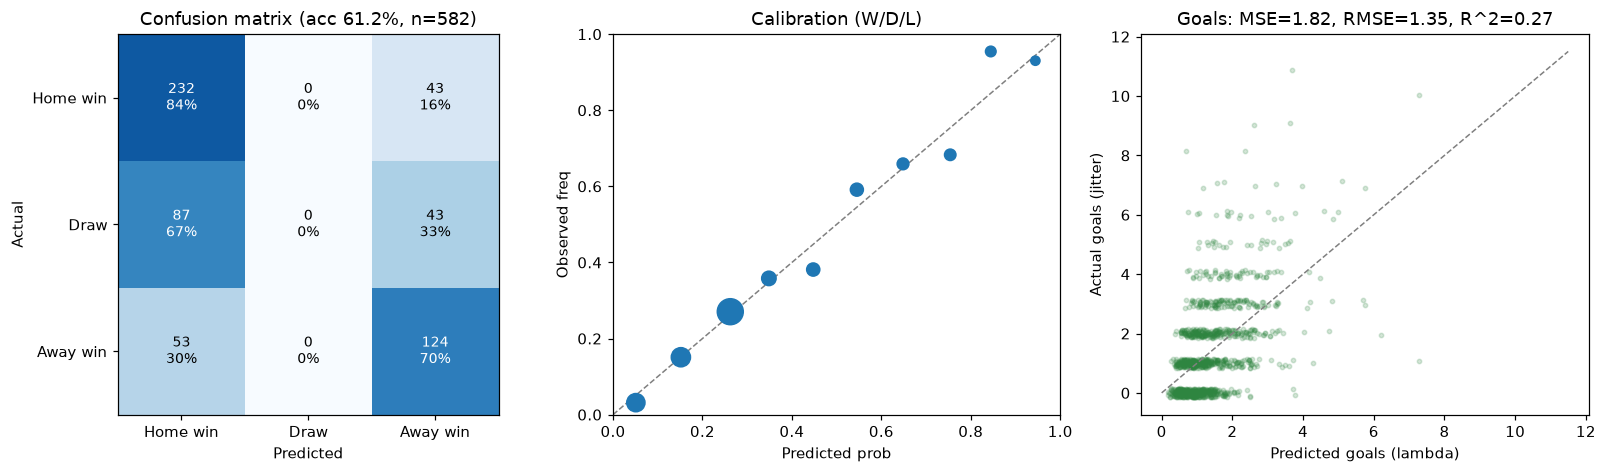

In [7]:
# ===== 6. 결과를 그림으로 보기 =====
# 숫자만 보면 어려우니 그래프 3개로 한눈에 봐요: (1)어디서 맞고 틀렸나 (2)확률이 정직한가 (3)골 예측이 맞나
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4)); labs = ["Home win","Draw","Away win"]

# (1) 혼동 행렬: 실제 결과(세로) vs 모델 예측(가로). 대각선이 진할수록 잘 맞힌 거예요.
cm = np.zeros((3,3), int)
for a_, p_ in zip(B.y, B.pred): cm[a_, p_] += 1
cmn = cm/cm.sum(1, keepdims=True); ax[0].imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax[0].set_xticks(range(3), labs); ax[0].set_yticks(range(3), labs); ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("Actual")
ax[0].set_title(f"Confusion matrix (acc {acc*100:.1f}%, n={len(B)})")
for rr in range(3):
    for cc in range(3):
        ax[0].text(cc, rr, f"{cm[rr,cc]}\n{cmn[rr,cc]*100:.0f}%", ha="center", va="center",
                   color="white" if cmn[rr,cc]>0.5 else "black", fontsize=9)
ax[0].grid(False)

# (2) 보정(calibration) 그래프: "60% 확률"이라고 말한 일이 진짜 60%쯤 일어났는지 확인. 점선에 가까울수록 정직한 모델.
pr = B[["pw","pd","pl"]].values; oh = np.zeros_like(pr); oh[np.arange(len(B)), B.y.values] = 1
pf, of = pr.ravel(), oh.ravel(); eg = np.linspace(0,1,11); idx = np.clip(np.digitize(pf, eg)-1, 0, 9)
xs, ys, ns = [], [], []
for b in range(10):
    msk = idx == b
    if msk.sum() > 0: xs.append(pf[msk].mean()); ys.append(of[msk].mean()); ns.append(msk.sum())
ax[1].plot([0,1],[0,1],"--",color="gray",lw=1); ax[1].scatter(xs, ys, s=np.array(ns)/2+15, color="#1f77b4", zorder=3)
ax[1].set_xlabel("Predicted prob"); ax[1].set_ylabel("Observed freq"); ax[1].set_title("Calibration (W/D/L)"); ax[1].set_xlim(0,1); ax[1].set_ylim(0,1)

# (3) 골 예측 산점도: 가로=예측한 골 수, 세로=실제 골 수. 점선 가까이 모일수록 잘 맞힌 거예요.
jit = np.random.default_rng(0).uniform(-0.15, 0.15, len(goals_true))   # 점이 겹치지 않게 살짝 흔들어 줌(보기 편하게)
ax[2].scatter(goals_pred, goals_true+jit, s=8, alpha=0.2, color="#2e8540")
mx = max(goals_pred.max(), goals_true.max())+0.5; ax[2].plot([0,mx],[0,mx],"--",color="gray",lw=1)
ax[2].set_xlabel("Predicted goals (lambda)"); ax[2].set_ylabel("Actual goals (jitter)")
ax[2].set_title(f"Goals: MSE={mse:.2f}, RMSE={mse**0.5:.2f}, R^2={r2:.2f}")
plt.tight_layout(); plt.show()


## 6-2. 잔차(residual) 분포 — 모델이 어느 쪽으로 빗나가나?
잔차 = (실제 골) − (예측 골). 0 근처에 좌우 대칭으로 모이면 편향 없이 잘 맞춘 거예요.
- **0보다 큰 쪽으로 치우침** → 모델이 골을 *적게* 예측(과소예측)하는 경향
- **0보다 작은 쪽으로 치우침** → 모델이 골을 *많이* 예측(과대예측)하는 경향

홈/원정을 따로 보면 홈 어드밴티지 같은 편향이 한쪽에만 남아 있는지 확인할 수 있어요.

In [ ]:
# ===== 6-2. 잔차 분포 그림 (홈/원정 따로) =====
# 5번에서 만든 시험용 예측(lam=홈 예상골, mu=원정 예상골)과 실제 골을 비교해 '잔차'를 봅니다.
try:
    import seaborn as sns; _HAS_SNS = True
except Exception:
    _HAS_SNS = False   # seaborn 없으면 matplotlib 히스토그램으로 대체

# 잔차 = 실제 - 예측  (양수=과소예측, 음수=과대예측)
res_home = te.goals_scored_home.values - lam
res_away = te.goals_scored_away.values - mu

fig, ax = plt.subplots(2, 2, figsize=(13, 7), gridspec_kw={"width_ratios":[1.3, 1]})
specs = [(0, res_home, lam, "Home", "#4c92c3"), (1, res_away, mu, "Away", "#56b46a")]

for row, res, pred, name, color in specs:
    mu_r, sd_r = res.mean(), res.std()   # 잔차의 평균(편향)과 표준편차(흩어짐)

    # (왼쪽) 잔차 히스토그램 + KDE 곡선
    if _HAS_SNS:
        sns.histplot(res, bins=30, kde=True, color=color, ax=ax[row, 0], edgecolor="white", linewidth=0.4)
    else:
        ax[row, 0].hist(res, bins=30, color=color, edgecolor="white", linewidth=0.4)
    ax[row, 0].axvline(0, color="k", ls="--", lw=1.2)                       # 이상적인 위치(잔차 0)
    ax[row, 0].axvline(mu_r, color="#e07b00", ls="--", lw=1.4)              # 실제 평균(편향)
    ax[row, 0].axvline(mu_r - sd_r, color="#a0522d", ls="--", lw=1, alpha=.8)  # 평균 ±1 표준편차
    ax[row, 0].axvline(mu_r + sd_r, color="#a0522d", ls="--", lw=1, alpha=.8)
    ax[row, 0].set_title(f"{name} Residuals  (mean={mu_r:+.2f}, std={sd_r:.2f})")
    ax[row, 0].set_xlabel("Residual (actual - predicted)"); ax[row, 0].set_ylabel("Count")

    # (오른쪽) 잔차 vs 예측골: 예측이 커질수록 잔차가 한쪽으로 쏠리면 편향이 있는 거예요.
    jit = np.random.default_rng(1).uniform(-0.06, 0.06, len(res))
    ax[row, 1].scatter(pred, res + jit, s=10, alpha=0.25, color=color)
    ax[row, 1].axhline(0, color="k", ls="--", lw=1.2)
    ax[row, 1].set_title(f"{name}: residual vs predicted")
    ax[row, 1].set_xlabel("Predicted goals"); ax[row, 1].set_ylabel("Residual")

plt.tight_layout(); plt.show()

print(f"홈  잔차 평균 {res_home.mean():+.3f}  (양수면 과소예측 경향)")
print(f"원정 잔차 평균 {res_away.mean():+.3f}")

## 7. 예측 — 체코 포함 (수정 전엔 불가했던 경기들)

팀A vs 팀B (중립):      lam_A / lam_B   |   A승 /  무  / B승
  South Africa   vs South Korea   :  0.66 / 1.60   |    15% /   26% /   59%
  Czech Republic vs Mexico        :  0.86 / 1.23   |    25% /   31% /   44%   <- 수정 전 불가
  Czech Republic vs South Africa  :  1.42 / 0.74   |    52% /   29% /   19%   <- 수정 전 불가
  South Korea    vs Czech Republic:  1.16 / 0.91   |    40% /   32% /   28%   <- 수정 전 불가


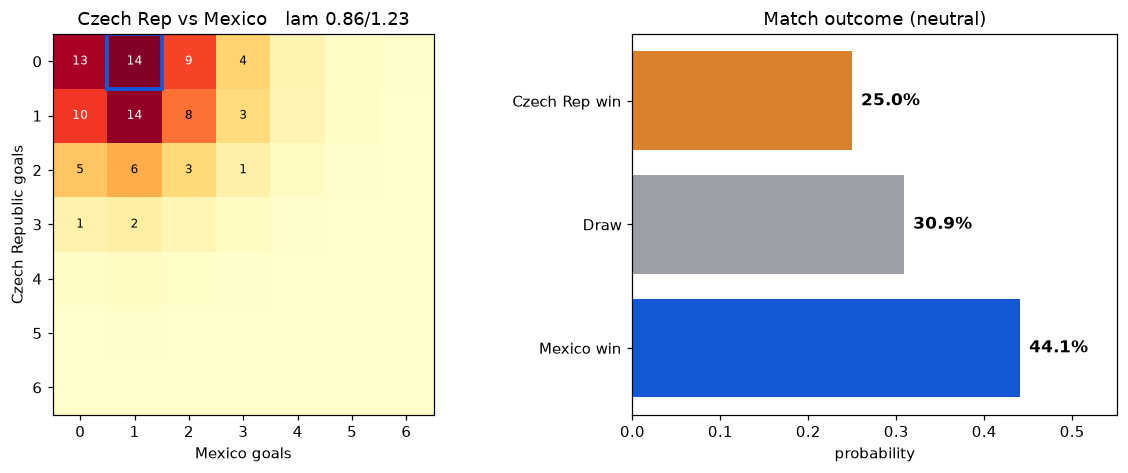

In [8]:
# ===== 7. 실제 경기 예측해 보기 (체코 포함!) =====
# 이제 모델로 아무 두 팀이나 붙여서 결과를 예측할 수 있어요. 예전엔 빠져 있던 체코도 이제 예측 가능!
mf, rf = fit(df[df.date < PRED_DATE], PRED_DATE)   # 예측 기준일까지의 모든 경기로 최종 모델 학습
demo = [("South Africa","South Korea"), ("Czech Republic","Mexico"),
        ("Czech Republic","South Africa"), ("South Korea","Czech Republic")]   # 예측해 볼 경기 목록
print("팀A vs 팀B (중립):      lam_A / lam_B   |   A승 /  무  / B승")
for a_, b_ in demo:
    L, M, P = predict(a_, b_, True, mf, rf); pw, pd_, pl = wdl(P)   # 예상 골과 승/무/패 확률
    flag = "   <- 수정 전 불가" if "Czech Republic" in (a_, b_) else ""
    print(f"  {a_:14s} vs {b_:14s}:  {L:.2f} / {M:.2f}   |  {pw*100:4.0f}% / {pd_*100:4.0f}% / {pl*100:4.0f}%{flag}")

# 체코 vs 멕시코 경기를 예로, 어떤 스코어가 나올지 색칠 표(히트맵)로 그려 봐요. 진한 칸일수록 그 스코어가 나올 확률이 높아요.
L, M, P = predict("Czech Republic","Mexico", True, mf, rf); pw, pd_, pl = wdl(P)
i, j = np.unravel_index(P[:7,:7].argmax(), (7,7))   # 가장 확률 높은 스코어 칸 위치 찾기
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4), gridspec_kw={"width_ratios":[1.25,1]}); G = P[:7,:7]
ax[0].imshow(G, cmap="YlOrRd", origin="upper"); ax[0].set_xticks(range(7)); ax[0].set_yticks(range(7))
ax[0].set_xlabel("Mexico goals"); ax[0].set_ylabel("Czech Republic goals"); ax[0].set_title(f"Czech Rep vs Mexico   lam {L:.2f}/{M:.2f}")
for rr in range(7):
    for cc in range(7):
        if G[rr,cc] >= 0.012:
            ax[0].text(cc, rr, f"{G[rr,cc]*100:.0f}", ha="center", va="center", fontsize=8,
                       color="white" if G[rr,cc]>G.max()*0.6 else "black")
ax[0].add_patch(Rectangle((j-0.5,i-0.5),1,1,fill=False,ec="#1558d6",lw=2.5)); ax[0].grid(False)   # 가장 유력한 스코어에 파란 네모 표시
# 오른쪽: 체코승 / 무승부 / 멕시코승 확률을 막대그래프로
vals=[pw,pd_,pl]; names=["Czech Rep win","Draw","Mexico win"]; cols=["#d9822b","#9aa0a6","#1558d6"]
ax[1].barh(range(3), vals, color=cols); ax[1].set_yticks(range(3), names); ax[1].invert_yaxis(); ax[1].set_xlim(0, max(vals)*1.25)
ax[1].set_xlabel("probability"); ax[1].set_title("Match outcome (neutral)")
for k, v in enumerate(vals): ax[1].text(v+0.01, k, f"{v*100:.1f}%", va="center", fontsize=11, fontweight="bold")
ax[1].grid(axis="y", alpha=0); plt.tight_layout(); plt.show()


## 8. 조별 순위(1·2·3위) + 3위 팀 상위 8팀 산출

2026 월드컵은 **12개조 × 4팀**. 각 조 **1·2위(24팀)** + **3위 12팀 중 상위 8팀** = 32팀이 32강에 진출한다.

- **순위 산정**: 각 조 라운드로빈(6경기)을 모델로 예측해 팀별 **기대 승점 xP**(= 3·P(승)+1·P(무)) 누적. 동률은 **기대 득실차 xGD → 기대 득점 xGF** 순으로 정렬. 정수 스코어로 승점을 매기면 무승부가 많아 동점이 속출하므로, 확률모델의 기대값으로 매끄럽게 순위를 가린다.
- **3위 상위 8팀**: 12개 조의 3위 팀을 동일 기준(xP → xGD → xGF)으로 한 줄로 세워 상위 8팀을 진출 처리(FIFA 실제 규정의 승점→득실차→득점 순서와 동일한 우선순위).
- 조 구성은 `example_submission.csv` 의 `Group Stage(A~L)` 라벨에서 자동 추출, 결과는 `group_standings.csv` / `third_place_ranking.csv` 로 저장.

In [9]:
# ===== 8. 조별리그 순위 매기기 + 32강 진출팀 뽑기 =====
# 2026 월드컵은 12개 조 × 4팀이에요. 각 조 1·2위(24팀) + 3위 중 잘한 8팀 = 총 32팀이 다음 라운드로 가요.
import re
from itertools import combinations

# 표기가 다른 팀 이름을 우리 점수표(ELO_NOW)에서 쓰는 이름으로 바꿔 주는 작은 사전
NAME = {"Bosnia-Herzegovina":"Bosnia and Herzegovina", "Cape Verde Islands":"Cape Verde",
        "Congo DR":"DR Congo", "Czechia":"Czech Republic"}
mapn = lambda x: NAME.get(x, x)

# --- 어떤 팀이 어느 조인지 example_submission.csv 파일에서 읽어옵니다 ---
ex = pd.read_csv("example_submission.csv")
groups = {}
for _, r in ex.iterrows():
    g = re.match(r"Group Stage\(([A-L])\)", str(r["type"]))   # "Group Stage(A)" 같은 글자에서 조 이름(A~L) 뽑기
    if g: groups.setdefault(g.group(1), set()).update([r["team1"], r["team2"]])
groups = {g: sorted(groups[g]) for g in sorted(groups)}
bad = [t for gg in groups.values() for t in gg if mapn(t) not in ELO_NOW]
assert not bad, f"ELO_NOW 에 없는 팀: {bad}"   # 점수표에 없는 팀이 있으면 멈추고 알려 줌(실수 방지)
print(f"조 {len(groups)}개 x 4팀 = {sum(len(v) for v in groups.values())}팀 로드 완료")

# --- 한 조(4팀)가 서로 다 붙는 6경기를 예측해서 팀별 "기대 승점"을 계산하는 함수 ---
# 기대 승점(xP) = 3 × 이길확률 + 1 × 비길확률. 실제 점수 대신 확률을 써서 동점 없이 매끄럽게 순위를 매겨요.
def group_table(teams):
    xP  = {t:0.0 for t in teams}; xGF = {t:0.0 for t in teams}; xGA = {t:0.0 for t in teams}  # 기대승점/기대득점/기대실점
    for a, b in combinations(teams, 2):   # 조 안의 모든 짝(6경기)
        L, M, P = predict(mapn(a), mapn(b), True, mf, rf); pw, pd_, pl = wdl(P)
        xP[a] += 3*pw + pd_; xP[b] += 3*pl + pd_     # 각 팀의 기대 승점 누적
        xGF[a] += L; xGA[a] += M; xGF[b] += M; xGA[b] += L   # 기대 득점/실점 누적
    tab = (pd.DataFrame([dict(team=t, xP=xP[t], xGD=xGF[t]-xGA[t], xGF=xGF[t]) for t in teams])
             .sort_values(["xP","xGD","xGF"], ascending=False).reset_index(drop=True))  # 승점->득실차->득점 순으로 정렬
    tab.index = tab.index + 1   # 1=1위
    return tab

# --- 12개 조를 모두 계산해서 순위를 출력하고, 각 조 3위 팀을 모읍니다 ---
print("\n================  조별 예측 순위 (모델 기대 승점 기준)  ================")
standings = {}; thirds = []
for g, teams in groups.items():
    tab = group_table(teams); standings[g] = tab
    print(f"\n[Group {g}]")
    for rank, row in tab.iterrows():
        print(f"  {rank}위  {row.team:20s}  xP {row.xP:4.2f}  xGD {row.xGD:+5.2f}  xGF {row.xGF:4.2f}")
    th = tab.loc[3]; thirds.append(dict(group=g, team=th.team, xP=th.xP, xGD=th.xGD, xGF=th.xGF))   # 3위 팀 저장

# --- 12개 조의 3위 팀들을 한 줄로 세워서, 잘한 순서대로 위 8팀만 32강 진출 ---
third_tab = (pd.DataFrame(thirds).sort_values(["xP","xGD","xGF"], ascending=False).reset_index(drop=True))
third_tab.index = third_tab.index + 1
third_tab["advance"] = third_tab.index <= 8   # 상위 8팀이면 진출(True)
print("\n================  3위 팀 순위 → 상위 8팀 진출 (32강)  ================")
for rank, row in third_tab.iterrows():
    print(f"  {rank:2d}.  Group {row.group}  {row.team:20s}  xP {row.xP:4.2f}  xGD {row.xGD:+5.2f}  xGF {row.xGF:4.2f}   [{'진출' if row.advance else '탈락'}]")

# --- 결과를 파일로 저장 (나중에 다시 볼 수 있게) ---
allrows = []
for g, tab in standings.items():
    for rank, row in tab.iterrows():
        allrows.append(dict(group=g, rank=rank, team=row.team,
                            xP=round(row.xP,3), xGD=round(row.xGD,3), xGF=round(row.xGF,3)))
pd.DataFrame(allrows).to_csv("group_standings.csv", index=False, encoding="utf-8-sig")        # 조별 전체 순위 저장
third_tab.assign(rank=third_tab.index).round(3).to_csv("third_place_ranking.csv", index=False, encoding="utf-8-sig")  # 3위 순위 저장
print("\n저장: group_standings.csv  /  third_place_ranking.csv")
print("32강 진출:  조별 1·2위 24팀  +  3위 상위 8팀  =  32팀")


조 12개 x 4팀 = 48팀 로드 완료

================  조별 예측 순위 (모델 기대 승점 기준)  ================

[Group A]
  1위  Mexico                xP 5.21  xGD +1.59  xGF 4.03
  2위  South Korea           xP 4.81  xGD +1.05  xGF 3.72
  3위  Czechia               xP 4.08  xGD +0.06  xGF 3.19
  4위  South Africa          xP 2.17  xGD -2.70  xGF 2.03

[Group B]
  1위  Switzerland           xP 5.94  xGD +2.66  xGF 4.77
  2위  Canada                xP 5.49  xGD +2.01  xGF 4.36
  3위  Bosnia-Herzegovina    xP 2.58  xGD -2.21  xGF 2.27
  4위  Qatar                 xP 2.42  xGD -2.46  xGF 2.18

[Group C]
  1위  Brazil                xP 5.86  xGD +2.56  xGF 4.68
  2위  Morocco               xP 4.40  xGD +0.51  xGF 3.48
  3위  Scotland              xP 4.34  xGD +0.42  xGF 3.43
  4위  Haiti                 xP 1.78  xGD -3.48  xGF 1.82

[Group D]
  1위  Paraguay              xP 4.45  xGD +0.55  xGF 3.37
  2위  Turkey                xP 4.10  xGD +0.10  xGF 3.14
  3위  Australia             xP 3.90  xGD -0.16  xGF 3.01
  4위  United State

In [10]:
# ===== 9. 모델을 파일로 저장하기 (다음 노트북이 이어서 사용) =====
# 32강 토너먼트는 매번 새로운 대진이 생겨서 미리 정해둘 수 없어요. 그래서 결과표 대신 "모델 자체"를 저장해요.
# 다음 노트북이 이 파일을 열어서 "이 팀 vs 저 팀" 예측을 바로 이어서 할 수 있게요.
import json as _json
_engine = {"ELO_NOW": ELO_NOW,                       # 모든 팀의 실력 점수
           "coef": [float(c) for c in mf.coef_],     # 모델이 배운 계수(실력차/홈여부가 골에 주는 영향)
           "intercept": float(mf.intercept_),        # 모델의 기본값
           "rho": float(rf), "MAXG": MAXG}           # Dixon-Coles 보정값, 최대 골 수
with open("wc_match_engine.json", "w", encoding="utf-8") as _f:
    _json.dump(_engine, _f, ensure_ascii=False)
print(f"저장: wc_match_engine.json  (ELO {len(ELO_NOW)}팀 + Poisson 계수 {list(mf.coef_.round(3))} + rho {rf:.3f})")


# ===== 10. 학습된 모델을 pickle(.pkl)로 저장 — 제출용 (평가자 재현용) =====
# 평가 기준: "pkl을 불러오면 값(두 팀)을 넣어 바로 결과가 나오게". 그래서 학습이 끝난 모델 전체를 통째로 저장해요.
# JSON과 달리 pickle 은 sklearn 모델 객체(mf)를 그대로 담을 수 있어서, predict.py 가 불러와 바로 예측할 수 있어요.
import pickle
_bundle = {
    "ELO_NOW": ELO_NOW,   # 모든 팀의 실력 점수 (이걸로 두 팀 실력차를 구함)
    "model":   mf,        # 학습된 Poisson 회귀 모델 (실력차 -> 예상 골 수)
    "rho":     float(rf), # Dixon-Coles 보정값 (적은 골 경기 보정)
    "MAXG":    MAXG,      # 스코어 계산 시 최대 골 수
    "NAME":    NAME,      # 팀 이름 표기 차이를 맞춰 주는 사전
}
with open("wc_model.pkl", "wb") as _pf:
    pickle.dump(_bundle, _pf)
print(f"저장: wc_model.pkl  (팀 {len(ELO_NOW)}개 + 학습모델 + rho {rf:.3f})  ->  predict.py 로 바로 예측 가능")


저장: wc_match_engine.json  (ELO 213팀 + Poisson 계수 [np.float64(0.168), np.float64(0.254)] + rho -0.061)
저장: wc_model.pkl  (팀 213개 + 학습모델 + rho -0.061)  ->  predict.py 로 바로 예측 가능
